# ResNet18 Model Calibration Evaluation

이 노트북은 ResNet18 모델이 테스트셋에 대해 얼마나 잘 calibration 되어있는지 평가합니다.

Calibration 메트릭:
- Expected Calibration Error (ECE)
- Maximum Calibration Error (MCE) 
- Brier Score
- Reliability Diagram
- Confidence Histogram

In [40]:
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pickle
import os
import natsort
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append('/home/honeynaps/data/shared/integrate/sleep_stage')
from sklearn.metrics import confusion_matrix, classification_report, brier_score_loss
from sklearn.preprocessing import label_binarize
from models.cnn_encoders import resnet18
from utils.transforms import build_transforms
# from utils.post_process import run_postprocess

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## Calibration 메트릭 함수 정의

In [41]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    """
    Expected Calibration Error (ECE) 계산
    
    Args:
        y_true: 실제 레이블 (N,)
        y_prob: 예측 확률 (N, num_classes)
        n_bins: bin 개수
    
    Returns:
        ECE 값
    """
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    max_probs = np.max(y_prob, axis=1)
    pred_labels = np.argmax(y_prob, axis=1)
    accuracies = (pred_labels == y_true)
    
    ece = 0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (max_probs > bin_lower) & (max_probs <= bin_upper)
        prop_in_bin = in_bin.mean()
        
        if prop_in_bin > 0:
            accuracy_in_bin = accuracies[in_bin].mean()
            avg_confidence_in_bin = max_probs[in_bin].mean()
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
    
    return ece

def maximum_calibration_error(y_true, y_prob, n_bins=10):
    """
    Maximum Calibration Error (MCE) 계산
    """
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    max_probs = np.max(y_prob, axis=1)
    pred_labels = np.argmax(y_prob, axis=1)
    accuracies = (pred_labels == y_true)
    
    mce = 0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (max_probs > bin_lower) & (max_probs <= bin_upper)
        prop_in_bin = in_bin.mean()
        
        if prop_in_bin > 0:
            accuracy_in_bin = accuracies[in_bin].mean()
            avg_confidence_in_bin = max_probs[in_bin].mean()
            mce = max(mce, np.abs(avg_confidence_in_bin - accuracy_in_bin))
    
    return mce

def compute_brier_score(y_true, y_prob):
    """
    Brier Score 계산 (다중 클래스)
    """
    n_classes = y_prob.shape[1]
    y_true_onehot = label_binarize(y_true, classes=range(n_classes))
    if n_classes == 2:
        y_true_onehot = np.hstack([1-y_true_onehot, y_true_onehot])
    
    brier_score = np.mean(np.sum((y_prob - y_true_onehot)**2, axis=1))
    return brier_score

def plot_reliability_diagram(y_true, y_prob, n_bins=10, title="Reliability Diagram"):
    """
    Reliability Diagram 그리기
    """
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    max_probs = np.max(y_prob, axis=1)
    pred_labels = np.argmax(y_prob, axis=1)
    accuracies = (pred_labels == y_true)
    
    bin_centers = []
    bin_accuracies = []
    bin_confidences = []
    bin_counts = []
    
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (max_probs > bin_lower) & (max_probs <= bin_upper)
        prop_in_bin = in_bin.mean()
        
        if prop_in_bin > 0:
            accuracy_in_bin = accuracies[in_bin].mean()
            avg_confidence_in_bin = max_probs[in_bin].mean()
            
            bin_centers.append((bin_lower + bin_upper) / 2)
            bin_accuracies.append(accuracy_in_bin)
            bin_confidences.append(avg_confidence_in_bin)
            bin_counts.append(in_bin.sum())
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Reliability diagram
    ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
    ax1.scatter(bin_confidences, bin_accuracies, s=[c/10 for c in bin_counts], 
               alpha=0.7, c='red', label='Model')
    ax1.set_xlabel('Mean Predicted Probability')
    ax1.set_ylabel('Fraction of Positives')
    ax1.set_title(f'{title} - Reliability')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Confidence histogram
    ax2.hist(max_probs, bins=n_bins, alpha=0.7, color='blue', edgecolor='black')
    ax2.set_xlabel('Confidence')
    ax2.set_ylabel('Count')
    ax2.set_title(f'{title} - Confidence Distribution')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

def plot_class_wise_calibration(y_true, y_prob, class_names=None, n_bins=10):
    """
    클래스별 calibration 분석
    """
    n_classes = y_prob.shape[1]
    if class_names is None:
        class_names = [f'Class {i}' for i in range(n_classes)]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i in range(min(n_classes, 5)):  # 최대 5개 클래스만 표시
        ax = axes[i]
        
        # 이진 분류 문제로 변환 (클래스 i vs 나머지)
        y_true_binary = (y_true == i).astype(int)
        y_prob_binary = y_prob[:, i]
        
        # Bin별 분석
        bin_boundaries = np.linspace(0, 1, n_bins + 1)
        bin_lowers = bin_boundaries[:-1]
        bin_uppers = bin_boundaries[1:]
        
        bin_centers = []
        bin_accuracies = []
        bin_confidences = []
        
        for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
            in_bin = (y_prob_binary > bin_lower) & (y_prob_binary <= bin_upper)
            
            if in_bin.sum() > 0:
                accuracy_in_bin = y_true_binary[in_bin].mean()
                avg_confidence_in_bin = y_prob_binary[in_bin].mean()
                
                bin_centers.append((bin_lower + bin_upper) / 2)
                bin_accuracies.append(accuracy_in_bin)
                bin_confidences.append(avg_confidence_in_bin)
        
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
        ax.scatter(bin_confidences, bin_accuracies, alpha=0.7)
        ax.set_xlabel('Mean Predicted Probability')
        ax.set_ylabel('Fraction of Positives')
        ax.set_title(f'{class_names[i]} (Class {i})')
        ax.grid(True, alpha=0.3)
    
    # 마지막 subplot에는 전체 confidence distribution
    if len(axes) > n_classes:
        ax = axes[-1]
        max_probs = np.max(y_prob, axis=1)
        ax.hist(max_probs, bins=n_bins, alpha=0.7, color='gray', edgecolor='black')
        ax.set_xlabel('Maximum Confidence')
        ax.set_ylabel('Count')
        ax.set_title('Overall Confidence Distribution')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

## 데이터셋 및 모델 설정

In [42]:
# CustomDataset 클래스 (evaluate_demo.py에서 가져옴)
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, data_list, label_list, num_channels=9, fs=50, transforms=None):
        self.data_list = [torch.tensor(data[:, :, :num_channels], dtype=torch.float32) for data in data_list]
        self.label_list = [torch.tensor(labels, dtype=torch.long) for labels in label_list]
        self.num_data = [data.shape[0] for data in self.data_list]
        self.data_list = torch.concat(self.data_list, dim=0).unsqueeze(1)
        self.label_list = torch.concat(self.label_list, dim=0)
        self.num_channels = num_channels
        self.fs = fs
        self.transform = transforms

        self.data_list, self.label_list = self._group_data(self.data_list, self.label_list, 1)
        self._permute_data()

    def _group_data(self, data, labels, n):
        grouped_data = []
        grouped_labels = []
        for idx in range(0, len(data) - n + 1):
            grouped_data.append(data[idx:idx+n]) 
            grouped_labels.append(labels[idx+n-1])  # Label for the last item in the group
        
        grouped_data = torch.stack(grouped_data)
        grouped_labels = torch.tensor(grouped_labels, dtype=torch.long)
        
        return grouped_data, grouped_labels

    def _permute_data(self):     
        self.data_list = self.data_list.reshape(-1, 1, self.data_list.size(3), self.data_list.size(4))
        self.data_list = self.data_list.permute(0, 3, 1, 2)

    def __len__(self):
        return len(self.data_list)
    
    def __getitem__(self, idx):
        data = self.data_list[idx]
        label = self.label_list[idx]

        if self.transform:
            original_shape = data.shape
            data = data.reshape(self.num_channels, -1)
            data, label = self.transform(data, label)
            data = data.reshape(original_shape)

        return data, label

In [43]:
# 하이퍼파라미터 설정
model_name = 'resnet18'
gpu = 0
seed = 5
batch_size = 128
num_channels = 9
fs = 50

# 시드 설정
torch.manual_seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed_all(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Transform 설정
val_transforms = ["NormaliseOnly"]
val_transforms = build_transforms(val_transforms, n_channels=num_channels)

# 데이터셋 경로
dataset_dir = f'/home/honeynaps/data/250718_CND/PICKLE/SLEEP_50_NOFILL_NEWPREP'
# dataset_dir = "/home/honeynaps/data/GOLDEN/PICKLE/SLEEP_50_NOFILL"
file_names = natsort.natsorted(os.listdir(dataset_dir))

print(f"Total test files: {len(file_names)}")

Total test files: 5


In [44]:
# 모델 로드
device = torch.device(f'cuda:{gpu}' if torch.cuda.is_available() else 'cpu')
model = resnet18(num_channels=num_channels, pretrained=False)
save_path = '/home/honeynaps/data/shared/sleep_stage/saved_models/pretrained_asam_ver3.pt'
model.load_state_dict(torch.load(save_path, weights_only=True, map_location=device))
model = model.to(device)
model.eval()

print(f"Model loaded on {device}")
print(f"Model architecture: {model_name}")

Model loaded on cuda:0
Model architecture: resnet18


## 테스트셋에서 예측 및 확률 수집

In [45]:
# 전체 테스트셋에 대한 예측 수행
all_y_true = []
all_y_prob = []
all_y_pred = []

print("Running inference on test set...")

with torch.no_grad():
    for file_idx, file_name in enumerate(file_names):
        if file_idx % 10 == 0:
            print(f"Processing file {file_idx+1}/{len(file_names)}: {file_name}")
        
        # 데이터 로드
        with open(os.path.join(dataset_dir, file_name), 'rb') as f:
            data_dict = pickle.load(f)

        val_dataset = CustomDataset([data_dict['x']], [data_dict['y']], 
                                  num_channels, fs, transforms=val_transforms)
        test_loader = torch.utils.data.DataLoader(
            val_dataset, 
            batch_size=batch_size,
            pin_memory=True, 
            shuffle=False
        )

        file_y_true = []
        file_y_prob = []
        
        for data, labels in test_loader:
            data, labels = data.to(device), labels.to(device)
            data = data.reshape(-1, num_channels, 1, 1500 * (fs // 50))
            
            # 모델 예측
            outputs = model(data)
            outputs = outputs.reshape(-1, outputs.size(-1))
            labels = labels.reshape(-1)
            
            # 확률 계산 (softmax)
            probs = F.softmax(outputs, dim=1)
            
            file_y_true.extend(labels.cpu().numpy())
            file_y_prob.extend(probs.cpu().numpy())
        
        all_y_true.extend(file_y_true)
        all_y_prob.extend(file_y_prob)

        acc = np.mean(np.argmax(file_y_prob, axis=1) == np.array(file_y_true))
        print(f"File {file_name} processed. Accuracy: {acc:.4f}")

# numpy 배열로 변환
all_y_true = np.array(all_y_true)
all_y_prob = np.array(all_y_prob)
all_y_pred = np.argmax(all_y_prob, axis=1)

print(f"\nCollected {len(all_y_true)} predictions")
print(f"Accuracy: {np.mean(all_y_pred == all_y_true):.4f}")
print(f"Class distribution: {np.bincount(all_y_true)}")

Running inference on test set...
Processing file 1/5: CND-241017R1_M-40-OV-SE.pickle


RuntimeError: cannot reshape tensor of 0 elements into shape [-1, 1, 0, 9] because the unspecified dimension size -1 can be any value and is ambiguous

## Calibration 메트릭 계산

In [ ]:
# Sleep stage 클래스 이름
sleep_stages = ['Wake', 'REM', 'N1', 'N2', 'N3']

# Calibration 메트릭 계산
ece = expected_calibration_error(all_y_true, all_y_prob, n_bins=10)
mce = maximum_calibration_error(all_y_true, all_y_prob, n_bins=10)
brier = compute_brier_score(all_y_true, all_y_prob)

print("=== CALIBRATION METRICS ===")
print(f"Expected Calibration Error (ECE): {ece:.4f}")
print(f"Maximum Calibration Error (MCE): {mce:.4f}")
print(f"Brier Score: {brier:.4f}")
print(f"Accuracy: {np.mean(all_y_pred == all_y_true):.4f}")

# 신뢰도 분포 분석
max_probs = np.max(all_y_prob, axis=1)
print(f"\n=== CONFIDENCE STATISTICS ===")
print(f"Mean confidence: {np.mean(max_probs):.4f}")
print(f"Median confidence: {np.median(max_probs):.4f}")
print(f"Min confidence: {np.min(max_probs):.4f}")
print(f"Max confidence: {np.max(max_probs):.4f}")
print(f"Std confidence: {np.std(max_probs):.4f}")

=== CALIBRATION METRICS ===
Expected Calibration Error (ECE): 0.1155
Maximum Calibration Error (MCE): 0.2844
Brier Score: 0.4478
Accuracy: 0.6679

=== CONFIDENCE STATISTICS ===
Mean confidence: 0.7834
Median confidence: 0.8330
Min confidence: 0.2603
Max confidence: 1.0000
Std confidence: 0.1937


## Reliability Diagram 및 Confidence Histogram

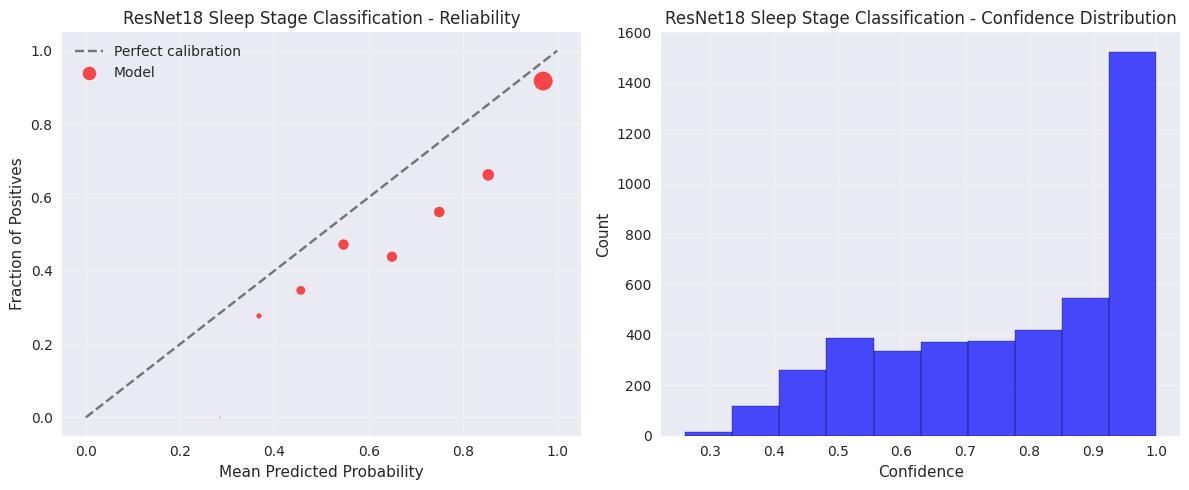

In [ ]:
# 전체 모델의 Reliability Diagram
fig = plot_reliability_diagram(all_y_true, all_y_prob, n_bins=10, 
                              title="ResNet18 Sleep Stage Classification")
plt.show()

## 클래스별 Calibration 분석

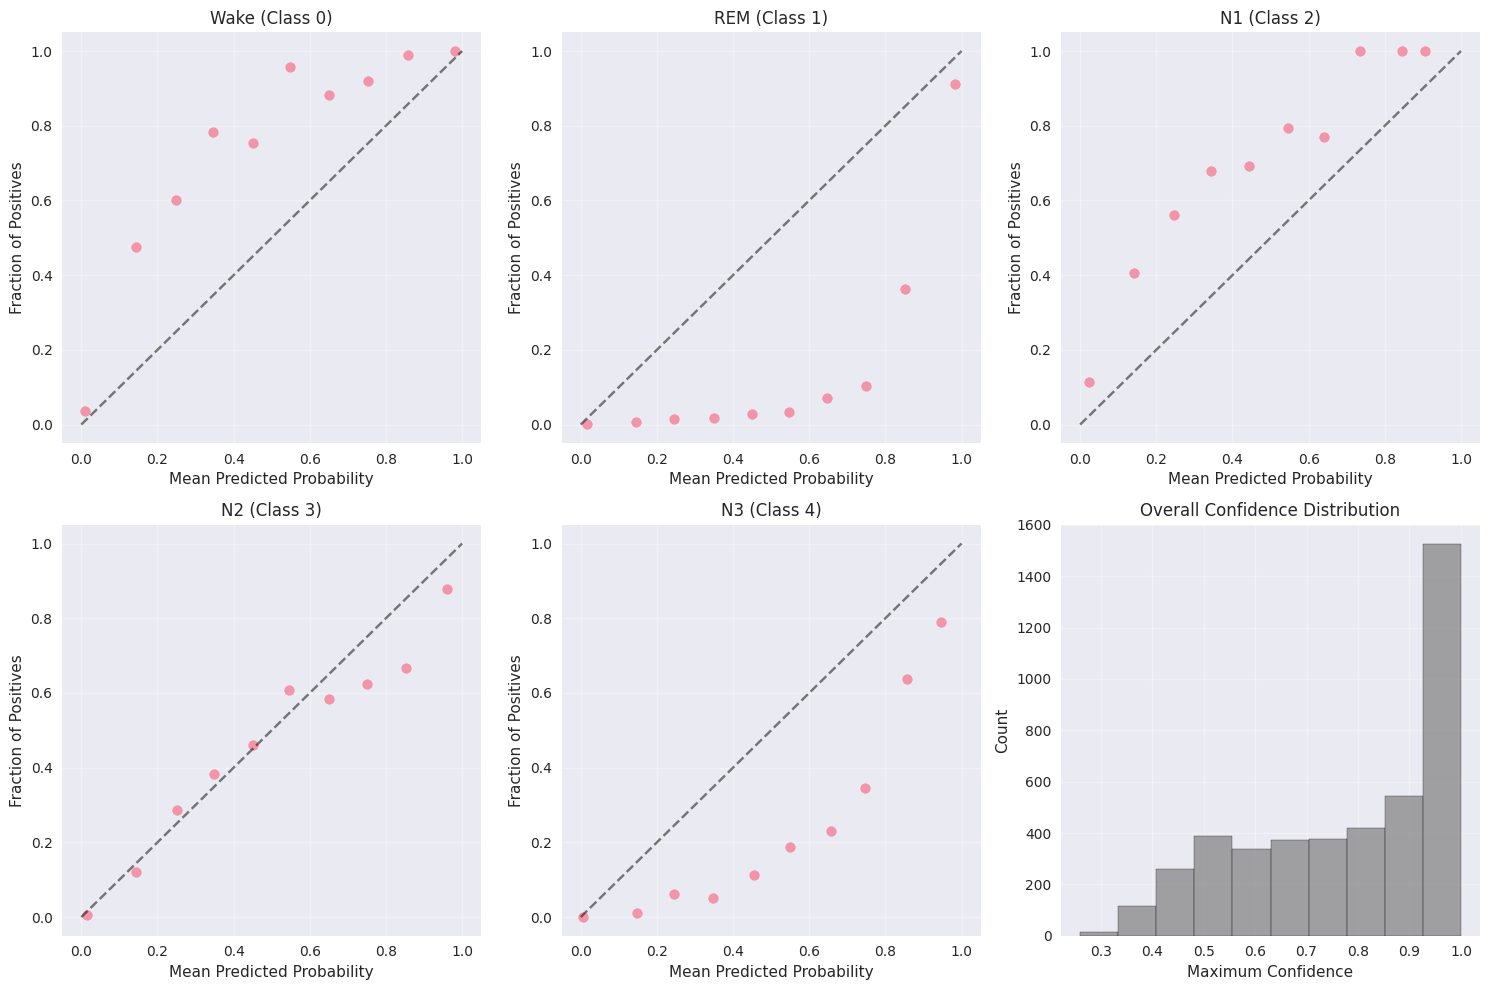

In [ ]:
# 클래스별 calibration 분석
fig = plot_class_wise_calibration(all_y_true, all_y_prob, 
                                 class_names=sleep_stages, n_bins=10)
plt.show()

## 클래스별 세부 메트릭

In [ ]:
# 클래스별 ECE 계산
print("=== CLASS-WISE CALIBRATION METRICS ===")

class_eces = []
class_briers = []

for i, stage_name in enumerate(sleep_stages):
    # 이진 분류 문제로 변환
    y_true_binary = (all_y_true == i).astype(int)
    y_prob_binary = all_y_prob[:, i]
    
    # 이진 분류용 ECE 계산
    y_prob_binary_2d = np.column_stack([1-y_prob_binary, y_prob_binary])
    class_ece = expected_calibration_error(y_true_binary, y_prob_binary_2d, n_bins=10)
    
    # Brier score (이진)
    class_brier = brier_score_loss(y_true_binary, y_prob_binary)
    
    class_eces.append(class_ece)
    class_briers.append(class_brier)
    
    # 클래스별 통계
    class_samples = np.sum(y_true_binary)
    mean_prob = np.mean(y_prob_binary[y_true_binary == 1]) if class_samples > 0 else 0
    
    print(f"{stage_name} (Class {i}):")
    print(f"  Samples: {class_samples}")
    print(f"  ECE: {class_ece:.4f}")
    print(f"  Brier Score: {class_brier:.4f}")
    print(f"  Mean prob for true positives: {mean_prob:.4f}")
    print()

=== CLASS-WISE CALIBRATION METRICS ===
Wake (Class 0):
  Samples: 1086
  ECE: 0.0354
  Brier Score: 0.0619
  Mean prob for true positives: 0.6699

REM (Class 1):
  Samples: 447
  ECE: 0.0078
  Brier Score: 0.0763
  Mean prob for true positives: 0.9315

N1 (Class 2):
  Samples: 1042
  ECE: 0.1346
  Brier Score: 0.1634
  Mean prob for true positives: 0.2155

N2 (Class 3):
  Samples: 1654
  ECE: 0.0427
  Brier Score: 0.1227
  Mean prob for true positives: 0.7639

N3 (Class 4):
  Samples: 128
  ECE: 0.0074
  Brier Score: 0.0234
  Mean prob for true positives: 0.7706



## 신뢰도별 정확도 분석

In [ ]:
# 신뢰도 구간별 정확도 분석
confidence_thresholds = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]

print("=== CONFIDENCE THRESHOLD ANALYSIS ===")
print("Threshold | Coverage | Accuracy | Count")
print("-" * 40)

for threshold in confidence_thresholds:
    high_conf_mask = max_probs >= threshold
    
    if np.sum(high_conf_mask) > 0:
        coverage = np.mean(high_conf_mask)
        accuracy = np.mean(all_y_pred[high_conf_mask] == all_y_true[high_conf_mask])
        count = np.sum(high_conf_mask)
        
        print(f"{threshold:8.2f} | {coverage:8.3f} | {accuracy:8.3f} | {count:5d}")
    else:
        print(f"{threshold:8.2f} | {0:8.3f} | {0:8.3f} | {0:5d}")

=== CONFIDENCE THRESHOLD ANALYSIS ===
Threshold | Coverage | Accuracy | Count
----------------------------------------
    0.50 |    0.891 |    0.709 |  3884
    0.60 |    0.776 |    0.745 |  3379
    0.70 |    0.662 |    0.797 |  2886
    0.80 |    0.544 |    0.849 |  2370
    0.90 |    0.399 |    0.917 |  1738
    0.95 |    0.297 |    0.959 |  1292
    0.99 |    0.144 |    0.997 |   626


## Confusion Matrix 및 Classification Report

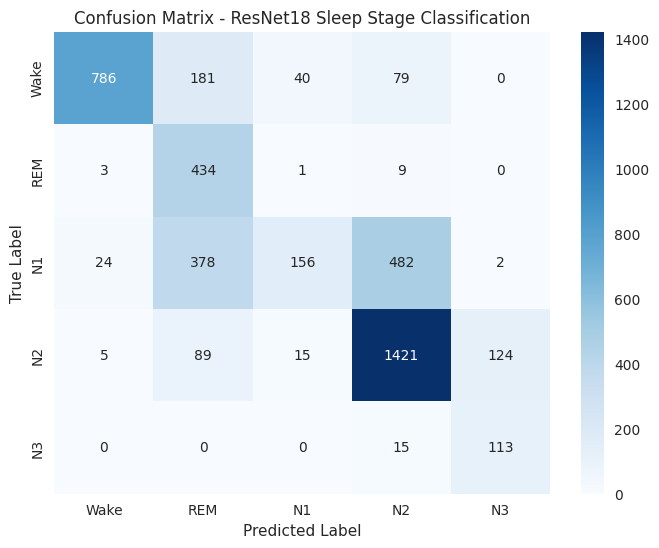


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

        Wake       0.96      0.72      0.83      1086
         REM       0.40      0.97      0.57       447
          N1       0.74      0.15      0.25      1042
          N2       0.71      0.86      0.78      1654
          N3       0.47      0.88      0.62       128

    accuracy                           0.67      4357
   macro avg       0.66      0.72      0.61      4357
weighted avg       0.74      0.67      0.64      4357



In [ ]:
# Confusion Matrix 시각화
cm = confusion_matrix(all_y_true, all_y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sleep_stages, yticklabels=sleep_stages)
plt.title('Confusion Matrix - ResNet18 Sleep Stage Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("\n=== CLASSIFICATION REPORT ===")
report = classification_report(all_y_true, all_y_pred, 
                             target_names=sleep_stages, 
                             zero_division=0)
print(report)

## 결과 요약 및 해석

In [ ]:
print("=== CALIBRATION SUMMARY ===")
print(f"Model: {model_name}")
print(f"Test samples: {len(all_y_true)}")
print(f"Test accuracy: {np.mean(all_y_pred == all_y_true):.4f}")
print()
print("Calibration Metrics:")
print(f"  Expected Calibration Error: {ece:.4f}")
print(f"  Maximum Calibration Error: {mce:.4f}")
print(f"  Brier Score: {brier:.4f}")
print()
print("Confidence Statistics:")
print(f"  Mean confidence: {np.mean(max_probs):.4f}")
print(f"  Median confidence: {np.median(max_probs):.4f}")
print(f"  Predictions with >90% confidence: {np.mean(max_probs > 0.9):.3f}")
print(f"  Predictions with >95% confidence: {np.mean(max_probs > 0.95):.3f}")

print("\n=== INTERPRETATION ===")
if ece < 0.05:
    print("✅ Excellent calibration (ECE < 0.05)")
elif ece < 0.1:
    print("✅ Good calibration (ECE < 0.1)")
elif ece < 0.15:
    print("⚠️ Moderate calibration (ECE < 0.15)")
else:
    print("❌ Poor calibration (ECE >= 0.15)")

if np.mean(max_probs > 0.9) > 0.8:
    print("⚠️ Model may be overconfident (many predictions >90% confidence)")
elif np.mean(max_probs < 0.6) > 0.5:
    print("⚠️ Model may be underconfident (many predictions <60% confidence)")
else:
    print("✅ Reasonable confidence distribution")

=== CALIBRATION SUMMARY ===
Model: resnet18
Test samples: 4357
Test accuracy: 0.6679

Calibration Metrics:
  Expected Calibration Error: 0.1155
  Maximum Calibration Error: 0.2844
  Brier Score: 0.4478

Confidence Statistics:
  Mean confidence: 0.7834
  Median confidence: 0.8330
  Predictions with >90% confidence: 0.399
  Predictions with >95% confidence: 0.297

=== INTERPRETATION ===
⚠️ Moderate calibration (ECE < 0.15)
✅ Reasonable confidence distribution


## 결론

이 노트북에서는 ResNet18 모델의 calibration을 다음 측면에서 평가했습니다:

1. **Expected Calibration Error (ECE)**: 전체적인 calibration 품질
2. **Maximum Calibration Error (MCE)**: 최대 calibration 오차
3. **Brier Score**: 확률적 예측의 정확성
4. **Reliability Diagram**: 신뢰도와 정확도의 관계 시각화
5. **클래스별 분석**: 각 sleep stage별 calibration 성능
6. **신뢰도 분석**: 모델의 confidence distribution 특성

이 분석을 통해 모델이 얼마나 신뢰할 수 있는 확률 예측을 제공하는지, 그리고 어떤 클래스에서 calibration이 좋지 않은지 파악할 수 있습니다.